# Detração de clientes: diagnóstico de causa-raiz via NLP

Exploração da tabela `fato_reviews_classificados`, produzida pelo pipeline
[`src/ia/classify_reviews.py`](../src/ia/classify_reviews.py), que lê as avaliações de detratores
(nota ≤ 2) no Data Warehouse, descobre uma taxonomia de queixas sem categorias pré-definidas e
classifica cada avaliação com schema estrito via Pydantic.

**Por que este módulo existe.** Dois terços dos clientes que dão nota 1 ou 2 receberam o pedido
**no prazo** (ver `analise_alavancas.ipynb`, seção 3). Para esses casos, nenhuma métrica operacional
da plataforma explica a insatisfação, só o texto da avaliação explica. Este notebook transforma
esse texto em dimensão consultável em SQL, cruzável com GMV, categoria de produto e vendedor.

O objetivo é dirigir a ação: penalizar atraso na vitrine é uma régua única; remediar catálogo e
conferência de expedição exige saber qual vendedor falha em quê.


In [1]:
import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 5)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

db_path = '../data/processed/olist.duckdb'
if not os.path.exists(db_path):
    db_path = 'data/processed/olist.duckdb'

conn = duckdb.connect(db_path, read_only=True)

# Um lote cuja chamada ao modelo falha entra como 'nao_classificado' com
# is_fallback = TRUE, e fica fora de qualquer percentual: contar esses registros
# como inferencia empurraria a categoria mais comum para cima sem deixar rastro.
# O bloco abaixo tolera bancos sem essas colunas para nao quebrar em execucoes antigas.
colunas = {r[0] for r in conn.execute("DESCRIBE fato_reviews_classificados").fetchall()}
TEM_SCHEMA_NOVO = 'is_fallback' in colunas

FILTRO_VALIDOS = ("is_fallback = FALSE" if TEM_SCHEMA_NOVO
                  else "motivo_especifico NOT LIKE '%fallback%'")

resumo = conn.execute(f"""
    SELECT COUNT(*) AS total,
           SUM(CASE WHEN {FILTRO_VALIDOS} THEN 0 ELSE 1 END) AS fallback,
           COUNT(DISTINCT CASE WHEN {FILTRO_VALIDOS} THEN categoria_primaria END) AS categorias,
           MAX(data_classificacao) AS ultima_execucao
    FROM fato_reviews_classificados
""").df()
display(resumo)

N_TOTAL = int(resumo['total'].iloc[0])
N_FALLBACK = int(resumo['fallback'].iloc[0])
N_VALIDOS = N_TOTAL - N_FALLBACK
IA_CONFIAVEL = N_TOTAL > 0 and (N_FALLBACK / N_TOTAL) <= 0.05

if not IA_CONFIAVEL:
    print(f"ATENCAO: {N_FALLBACK} de {N_TOTAL} registros ({N_FALLBACK / max(N_TOTAL, 1):.0%}) sao de")
    print("lotes em que a classificacao falhou. As distribuicoes abaixo NAO devem ser citadas.")
    print("Execute novamente antes de usar estes numeros:  python src/ia/classify_reviews.py")
    if not TEM_SCHEMA_NOVO:
        print("A tabela tambem esta no schema anterior (sem is_fallback / run_id).")
else:
    print(f"{N_VALIDOS} avaliacoes classificadas com sucesso, {N_FALLBACK} descartadas.")


,total,fallback,categorias,ultima_execucao
0,40,0.00,5,2026-08-18 02:20:36.173812


40 avaliacoes classificadas com sucesso, 0 descartadas.


## 1. Dimensão da amostra e margem de erro

A classificação roda sobre uma amostra aleatória com semente fixa, não sobre a base inteira, o
custo de API cresce linear com o volume e o objetivo aqui é estimar a distribuição de causas, não
etiquetar cada pedido.

Isso exige declarar o tamanho da amostra junto com qualquer percentual. Um número como "35,3% das
queixas" calculado sobre algumas centenas de avaliações aparenta a precisão de um censo, e não tem.


In [2]:
universo = conn.execute("""
    SELECT COUNT(*) FROM fato_pedidos
    WHERE review_score <= 2
      AND review_comment_message IS NOT NULL
      AND TRIM(review_comment_message) != ''
""").fetchone()[0]

margem = 1.96 * (0.25 / max(N_VALIDOS, 1)) ** 0.5 * 100

print(f"Universo de detratores com texto: {universo:,} pedidos")
print(f"Amostra classificada:             {N_VALIDOS} ({N_VALIDOS / universo:.1%} do universo)")
print(f"Margem de erro a 95%:             +/- {margem:.1f} p.p.")
print()
print("Leitura: os percentuais a seguir indicam ordem de grandeza e ranking entre categorias,")
print(f"nao medida exata. Uma diferenca menor que {margem:.0f} p.p. entre duas categorias nao e")
print("distinguivel com esta amostra.")

# Confere se o filtro de detracao aplicado no pipeline corresponde ao declarado.
display(conn.execute(f"""
    SELECT p.review_score, COUNT(*) AS avaliacoes
    FROM fato_reviews_classificados rc
    JOIN fato_pedidos p ON rc.order_id = p.order_id
    WHERE {FILTRO_VALIDOS}
    GROUP BY 1 ORDER BY 1
""").df())


Universo de detratores com texto: 10,493 pedidos
Amostra classificada:             40 (0.4% do universo)
Margem de erro a 95%:             +/- 15.5 p.p.

Leitura: os percentuais a seguir indicam ordem de grandeza e ranking entre categorias,
nao medida exata. Uma diferenca menor que 15 p.p. entre duas categorias nao e
distinguivel com esta amostra.


,review_score,avaliacoes
0,1,35
1,2,5


## 2. Taxonomia descoberta e distribuição das queixas

As categorias não foram definidas por nós: o modelo recebeu uma amostra de avaliações e recebeu a
tarefa de propor de 4 a 6 agrupamentos mutuamente exclusivos. A decisão por descoberta em vez de
categorias fixas está registrada na ADR 009, categorias definidas a priori carregam viés de
confirmação e tendem a não cobrir o que os clientes de fato escrevem.


,categoria_primaria,queixas,pct
0,logistica_atraso_extravio,18,45.00
1,qualidade_avaria_falsificacao,8,20.00
2,atendimento_sac_estorno,6,15.00
3,produto_divergente_incompleto,6,15.00
4,problemas_entrega_frete,2,5.00


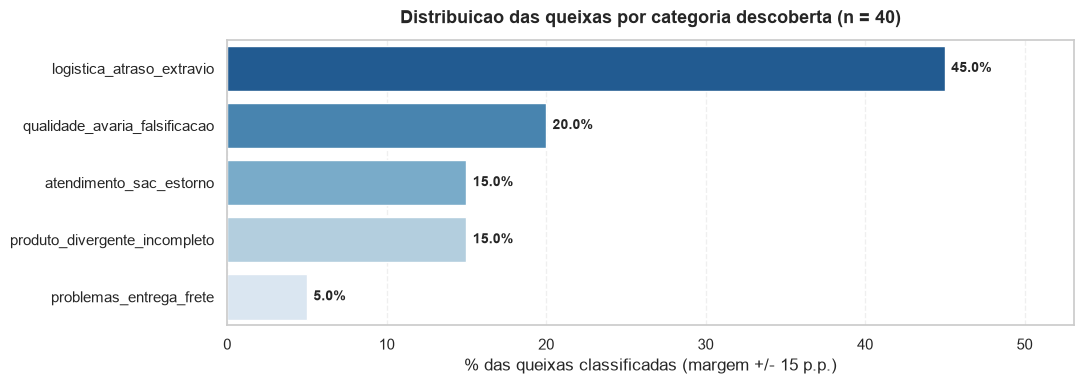

In [3]:
query_dist = f"""
    SELECT categoria_primaria,
           COUNT(*) AS queixas,
           ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM fato_reviews_classificados
    WHERE {FILTRO_VALIDOS}
    GROUP BY 1 ORDER BY queixas DESC
"""
df_dist = conn.execute(query_dist).df()
display(df_dist)

if len(df_dist) > 0:
    plt.figure(figsize=(11, 4))
    ax = sns.barplot(data=df_dist, x='pct', y='categoria_primaria', palette='Blues_r')
    plt.title(f'Distribuicao das queixas por categoria descoberta (n = {N_VALIDOS})',
              fontsize=13, fontweight='bold', pad=12)
    plt.xlabel(f'% das queixas classificadas (margem +/- {margem:.0f} p.p.)')
    plt.ylabel('')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', (p.get_width() + 0.4, p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=10, fontweight='bold')
    plt.xlim(0, df_dist['pct'].max() * 1.18)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


## 3. Severidade: volume não é o mesmo que gravidade

A categoria mais frequente não é necessariamente a mais urgente. O modelo classifica cada queixa em
severidade alta, média ou baixa, o que permite separar o ofensor volumétrico do ofensor crítico,
distinção que muda a ordem de prioridade operacional.


,categoria_primaria,total,alta,media,baixa,pct_alta
0,atendimento_sac_estorno,6,5.00,1.00,0.00,83.30
1,qualidade_avaria_falsificacao,8,6.00,2.00,0.00,75.00
2,produto_divergente_incompleto,6,4.00,2.00,0.00,66.70
3,logistica_atraso_extravio,18,11.00,6.00,1.00,61.10
4,problemas_entrega_frete,2,0.00,2.00,0.00,0.00


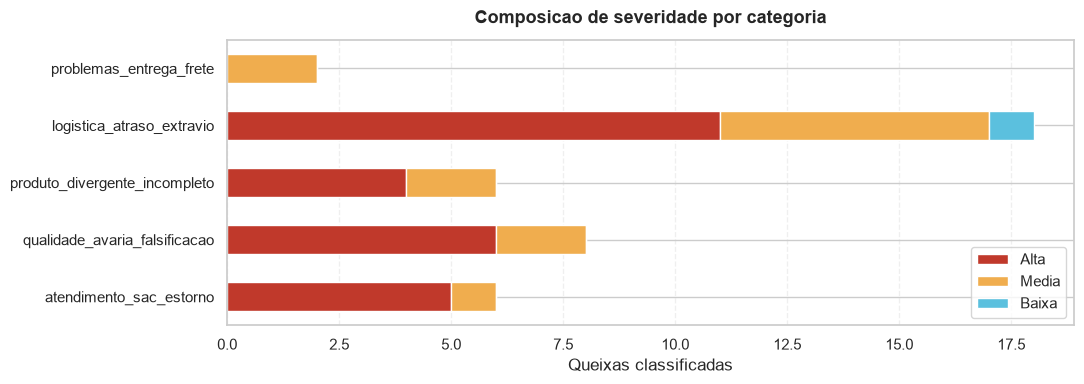

Maior ofensor em volume:    logistica_atraso_extravio (18 queixas)
Maior ofensor em gravidade: atendimento_sac_estorno (83% de severidade alta)


In [4]:
query_sev = f"""
    SELECT categoria_primaria,
           COUNT(*) AS total,
           SUM(CASE WHEN severidade = 'alta' THEN 1 ELSE 0 END) AS alta,
           SUM(CASE WHEN severidade = 'media' THEN 1 ELSE 0 END) AS media,
           SUM(CASE WHEN severidade = 'baixa' THEN 1 ELSE 0 END) AS baixa,
           ROUND(100.0 * SUM(CASE WHEN severidade = 'alta' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_alta
    FROM fato_reviews_classificados
    WHERE {FILTRO_VALIDOS}
    GROUP BY 1 ORDER BY pct_alta DESC
"""
df_sev = conn.execute(query_sev).df()
display(df_sev)

if len(df_sev) > 0:
    df_sev.set_index('categoria_primaria')[['alta', 'media', 'baixa']].plot(
        kind='barh', stacked=True, color=['#C0392B', '#F0AD4E', '#5BC0DE'], figsize=(11, 4))
    plt.title('Composicao de severidade por categoria', fontsize=13, fontweight='bold', pad=12)
    plt.xlabel('Queixas classificadas')
    plt.ylabel('')
    plt.legend(['Alta', 'Media', 'Baixa'], loc='lower right')
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    top_vol = df_sev.sort_values('total', ascending=False).iloc[0]
    top_grav = df_sev.iloc[0]
    print(f"Maior ofensor em volume:    {top_vol.categoria_primaria} ({int(top_vol.total)} queixas)")
    print(f"Maior ofensor em gravidade: {top_grav.categoria_primaria} ({top_grav.pct_alta:.0f}% de severidade alta)")


## 4. Falha controlável vs fricção logística

Esta é a seção que conecta o módulo de IA à recomendação ao CEO.

Cruzando a categoria descoberta com a pontualidade real da entrega, as queixas se separam em dois
grupos com donos e tratamentos diferentes. Queixas de atraso em pedidos efetivamente atrasados são
fricção logística: malha, transportadora, prazo prometido. Queixas de item faltante, produto
divergente ou defeito em pedidos entregues **no prazo** são falha controlável pelo vendedor: erro de
catálogo, de conferência de expedição ou de qualidade.

A segunda categoria é a que a plataforma hoje não vê, porque o SLA de entrega foi cumprido.


In [5]:
query_ponte = f"""
    SELECT rc.categoria_primaria,
           SUM(CASE WHEN p.atrasou THEN 1 ELSE 0 END) AS em_pedido_atrasado,
           SUM(CASE WHEN NOT p.atrasou THEN 1 ELSE 0 END) AS em_pedido_pontual
    FROM fato_reviews_classificados rc
    JOIN fato_pedidos p ON rc.order_id = p.order_id
    WHERE {FILTRO_VALIDOS} AND p.atrasou IS NOT NULL
    GROUP BY 1 ORDER BY em_pedido_pontual DESC
"""
display(conn.execute(query_ponte).df())

# GMV e concentracao por vendedor: dirige a acao de remediacao.
query_gmv = f"""
    SELECT rc.categoria_primaria,
           COUNT(DISTINCT rc.order_id) AS pedidos,
           ROUND(SUM(i.price), 2) AS gmv_afetado,
           ROUND(SUM(i.freight_value), 2) AS frete_envolvido
    FROM fato_reviews_classificados rc
    JOIN fato_itens i ON rc.order_id = i.order_id
    WHERE {FILTRO_VALIDOS}
    GROUP BY 1 ORDER BY gmv_afetado DESC
"""
display(conn.execute(query_gmv).df())

print("Vendedores com mais queixas de falha controlavel (catalogo / expedicao):")
display(conn.execute(f"""
    SELECT v.state AS uf,
           COUNT(DISTINCT rc.order_id) AS queixas,
           ROUND(SUM(i.price), 2) AS gmv_afetado
    FROM fato_reviews_classificados rc
    JOIN fato_itens i ON rc.order_id = i.order_id
    JOIN dim_vendedor v ON i.seller_id = v.seller_id
    WHERE {FILTRO_VALIDOS}
      AND (rc.categoria_primaria LIKE '%incompleto%'
        OR rc.categoria_primaria LIKE '%divergente%'
        OR rc.categoria_primaria LIKE '%defeito%')
    GROUP BY v.seller_id, v.state
    ORDER BY queixas DESC LIMIT 8
""").df())

print("Categorias de produto com mais queixas:")
display(conn.execute(f"""
    SELECT pr.category_name AS categoria_produto,
           COUNT(DISTINCT rc.order_id) AS queixas,
           ROUND(SUM(i.price), 2) AS gmv_afetado
    FROM fato_reviews_classificados rc
    JOIN fato_itens i ON rc.order_id = i.order_id
    JOIN dim_produto pr ON i.product_id = pr.product_id
    WHERE {FILTRO_VALIDOS}
    GROUP BY 1 ORDER BY queixas DESC LIMIT 8
""").df())


,categoria_primaria,em_pedido_atrasado,em_pedido_pontual
0,qualidade_avaria_falsificacao,0.00,8.00
1,logistica_atraso_extravio,10.00,7.00
2,produto_divergente_incompleto,0.00,6.00
3,atendimento_sac_estorno,0.00,4.00
4,problemas_entrega_frete,1.00,1.00


,categoria_primaria,pedidos,gmv_afetado,frete_envolvido
0,logistica_atraso_extravio,18,1645.05,301.95
1,qualidade_avaria_falsificacao,8,818.57,175.38
2,produto_divergente_incompleto,6,790.59,213.10
3,problemas_entrega_frete,2,437.80,51.06
4,atendimento_sac_estorno,5,352.58,170.16


Vendedores com mais queixas de falha controlavel (catalogo / expedicao):


,uf,queixas,gmv_afetado
0,SP,2,229.60
1,SP,1,119.85
2,MG,1,38.90
3,SP,1,149.90
4,SP,1,173.34
5,SP,1,79.00


Categorias de produto com mais queixas:


,categoria_produto,queixas,gmv_afetado
0,sports_leisure,4,468.90
1,computers_accessories,4,288.69
2,garden_tools,4,447.40
3,health_beauty,3,333.80
4,unknown,3,436.31
5,housewares,3,246.50
6,bed_bath_table,3,257.88
7,perfumery,3,452.79


## 5. Síntese

**O que este módulo entrega.** Uma dimensão de causa-raiz consultável em SQL, derivada de texto
livre, cruzável com GMV, vendedor e categoria de produto. Sem ela, dois terços da detração da
plataforma — os pedidos entregues no prazo cujo cliente ainda ficou insatisfeito — permanecem sem
diagnóstico, porque nenhum indicador operacional registra o que deu errado.

**Limitações do método:**

- amostra aleatória com semente fixa, não censo, a margem de erro da seção 1 se aplica a todo
  percentual deste notebook;
- a taxonomia é redescoberta a cada execução, então rótulos podem mudar entre rodadas; o `run_id`
  na tabela permite rastrear qual execução gerou cada linha;
- a classificação não foi validada contra avaliação humana, o que seria o próximo passo natural
  para medir acurácia por categoria.


In [6]:
conn.close()
print("Analise concluida e conexao encerrada.")


Analise concluida e conexao encerrada.
